In [2]:
import matplotlib.pyplot as plt
import numpy as np
import mplhep as hep
np.random.seed(2)

hep.style.use("plothist")

In [3]:
H = np.histogram(np.random.normal(2.5, .5, 100), bins=np.arange(0,6, 0.5))
print("Type:", type(H))
h, bins = H
print("Values:", h)
print("Bins:", bins)

Type: <class 'tuple'>
Values: [ 0  0  6 12 35 31 14  2  0  0  0]
Bins: [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5]


/home/azhou/.local/lib/python3.10/site-packages/mplhep/_utils.py:435: UserWarning: Integer weights indicate poissonian data. Will calculate Garwood interval if ``scipy`` is installed. Otherwise errors will be set to ``sqrt(w2)``.
  _plottable.errors(assume_variances_equal_values=True)
/home/azhou/.local/lib/python3.10/site-packages/mplhep/_utils.py:1095: UserWarning: Integer weights indicate poissonian data. Will calculate Garwood interval if ``scipy`` is installed. Otherwise errors will be set to ``sqrt(w2)``.
  self.errors()


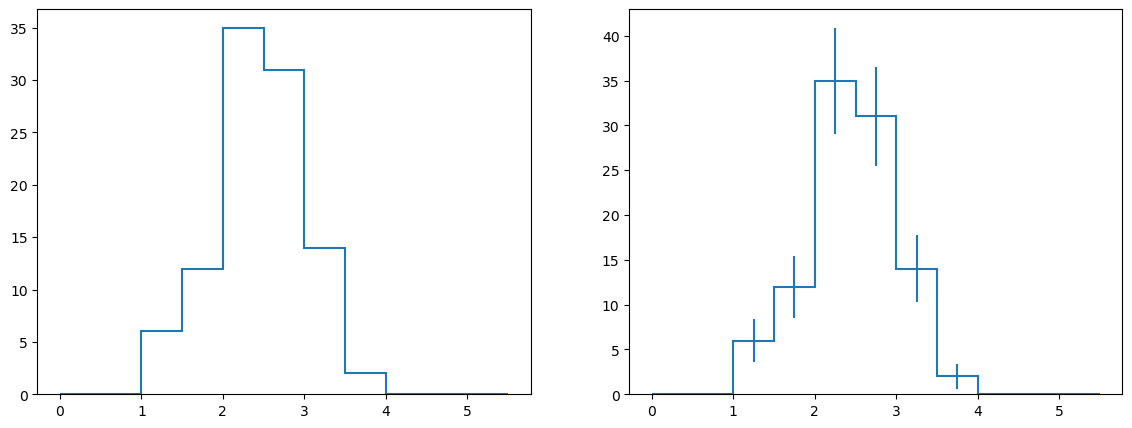

In [4]:
f, axs = plt.subplots(1,2, figsize=(14, 5))

hep.histplot(H, ax=axs[0])
hep.histplot(h, bins, yerr=True, ax=axs[1]);

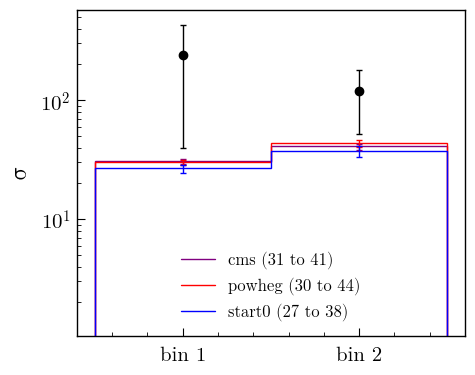

In [7]:
obs = np.array([240.0, 120.0])
cms    = np.array([31.0, 41.0])
powheg = np.array([30.1, 43.8])
start0 = np.array([26.7, 37.7])

obs_err_up = np.array([200, 68])
obs_err_down = np.array([190, 61])
cms_err_down = np.array([1, 2])
cms_err_up = np.array([2, 3])
powheg_err_down = np.array([1.26, 2.41])
powheg_err_up = np.array([1.62, 3.06])
start0_err_down = np.array([1.8, 3.7])
start0_err_up = np.array([2.1, 4.5])

edges = np.array([1,2,3])
centers = (edges[:-1] + edges[1:]) / 2

fig, ax = plt.subplots(figsize=(5,4))

hep.histplot(
    cms, bins=edges, histtype="barstep",
    label="cms (31 to 41)", ax=ax, color = 'purple'
)
hep.histplot(
    powheg, bins=edges, histtype="barstep",
    label="powheg (30 to 44)", ax=ax, color = 'red'
)
hep.histplot(
    start0, bins=edges, histtype="barstep",
    label="start0 (27 to 38)", ax=ax, color = 'blue'
)
# hep.scatterplot(
#     obs, bins=edges, histtype="barstep",
#     label="start0 (240 to 120)", ax=ax
# )

ax.set_xticks([1.5, 2.5])
ax.set_xticklabels(["bin 1", "bin 2"])
ax.set_ylabel(r"$\sigma$")
ax.set_yscale('log')

ax.errorbar(
    centers,
    cms,
    yerr=[cms_err_up, cms_err_down],
    fmt="none",
    capsize=2,
    elinewidth=1,
    color = 'purple'
)

ax.errorbar(
    centers,
    powheg,
    yerr=[powheg_err_up, powheg_err_down],
    fmt="none",
    capsize=2,
    elinewidth=1,
    color="red"
)

ax.errorbar(
    centers,
    obs,
    yerr=[obs_err_up, obs_err_down],
    fmt="o",
    capsize=2,
    elinewidth=1,
    color = 'black'
)

ax.errorbar(
    centers,
    start0,
    yerr=[start0_err_up, start0_err_down],
    fmt="none",
    capsize=2,
    elinewidth=1,
    color = 'blue'
)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()
